In [57]:
import os

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_33e66174a718900ac6b08f448b49830b'

In [58]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('classify-leaves')

print("Path to competition files:", path)

Path to competition files: /root/.cache/kagglehub/competitions/classify-leaves


In [59]:
import os

print(os.listdir(path))

['sample_submission.csv', 'test.csv', 'train.csv', 'images']


In [60]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import matplotlib.pyplot as plt
import torchvision.models as models
# This is for the progress bar.
from tqdm import tqdm

In [61]:
train_df = pd.read_csv(
    '/root/.cache/kagglehub/competitions/classify-leaves/train.csv'
)

train_df.head()

,image,label
0,images/0.jpg,maclura_pomifera
1,images/1.jpg,maclura_pomifera
2,images/2.jpg,maclura_pomifera
3,images/3.jpg,maclura_pomifera
4,images/4.jpg,maclura_pomifera


In [62]:
#提取类别，给类别编号，再建立反向映射
leave_labels=sorted(list(set(train_df['label'])))
n_classes=len(leave_labels)
print(n_classes)
class_to_num=dict(zip(leave_labels,range(n_classes)))
print(class_to_num)
num_to_class={v:k for k,v in class_to_num.items()}
print(num_to_class)


176
{'abies_concolor': 0, 'abies_nordmanniana': 1, 'acer_campestre': 2, 'acer_ginnala': 3, 'acer_griseum': 4, 'acer_negundo': 5, 'acer_palmatum': 6, 'acer_pensylvanicum': 7, 'acer_platanoides': 8, 'acer_pseudoplatanus': 9, 'acer_rubrum': 10, 'acer_saccharinum': 11, 'acer_saccharum': 12, 'aesculus_flava': 13, 'aesculus_glabra': 14, 'aesculus_hippocastamon': 15, 'aesculus_pavi': 16, 'ailanthus_altissima': 17, 'albizia_julibrissin': 18, 'amelanchier_arborea': 19, 'amelanchier_canadensis': 20, 'amelanchier_laevis': 21, 'asimina_triloba': 22, 'betula_alleghaniensis': 23, 'betula_jacqemontii': 24, 'betula_lenta': 25, 'betula_nigra': 26, 'betula_populifolia': 27, 'broussonettia_papyrifera': 28, 'carpinus_betulus': 29, 'carpinus_caroliniana': 30, 'carya_cordiformis': 31, 'carya_glabra': 32, 'carya_ovata': 33, 'carya_tomentosa': 34, 'castanea_dentata': 35, 'catalpa_bignonioides': 36, 'catalpa_speciosa': 37, 'cedrus_atlantica': 38, 'cedrus_deodara': 39, 'cedrus_libani': 40, 'celtis_occidentalis'

In [63]:
class LeavesDataset(Dataset):
  def __init__(self, csv_path, file_path, mode='train', valid_ratio=0.2, resize_height=256, resize_width=256):
    self.resize_height=resize_height
    self.resize_width=resize_width
    self.file_path=file_path
    self.mode=mode
    self.data_info=pd.read_csv(csv_path)
    self.data_len=len(self.data_info.index)
    self.train_len=int(self.data_len*(1-valid_ratio))
    if self.mode=="train":
      self.train_image=np.asarray(self.data_info.iloc[:self.train_len,0])
      self.train_label=np.asarray(self.data_info.iloc[:self.train_len,1])
      self.image_arr = self.train_image
      self.label_arr = self.train_label
    elif mode == 'valid':
      self.valid_image = np.asarray(self.data_info.iloc[self.train_len:, 0])
      self.valid_label = np.asarray(self.data_info.iloc[self.train_len:, 1])
      self.image_arr = self.valid_image
      self.label_arr = self.valid_label
    elif mode == 'test':
      self.test_image = np.asarray(self.data_info.iloc[:, 0])
      self.image_arr = self.test_image
    self.real_len = len(self.image_arr)
    print('Finished reading the {} set of Leaves Dataset ({} samples found)'
              .format(mode, self.real_len))

  #数据提取
  def __getitem__(self, index):
    single_image_name = self.image_arr[index]
    img_as_img = Image.open(self.file_path + single_image_name)
    if self.mode=="train":
      transform=transforms.Compose([transforms.Resize((224,224)),
      transforms.RandomHorizontalFlip(p=0.5), # 数据增强
      transforms.ToTensor()])
    else:
      transform=transforms.Compose([transforms.Resize((224,224)),
      transforms.ToTensor()])
    img_as_img=transform(img_as_img)
    if self.mode=="test":
      return img_as_img
    else:
      label = self.label_arr[index]
      number_label = class_to_num[label]
      return img_as_img, number_label
      #返回每一个index对应的图片数据和对应的label
  def __len__(self):
    return self.real_len

In [64]:
train_path = '/root/.cache/kagglehub/competitions/classify-leaves/train.csv'

test_path = '/root/.cache/kagglehub/competitions/classify-leaves/test.csv'


img_path = '/root/.cache/kagglehub/competitions/classify-leaves/'

train_dataset = LeavesDataset(
    train_path,
    img_path,
    mode='train'
)

val_dataset = LeavesDataset(
    train_path,
    img_path,
    mode='valid'
)

test_dataset = LeavesDataset(
    test_path,
    img_path,
    mode='test'
)

Finished reading the train set of Leaves Dataset (14682 samples found)
Finished reading the valid set of Leaves Dataset (3671 samples found)
Finished reading the test set of Leaves Dataset (8800 samples found)


In [65]:
train_loader = torch.utils.data.DataLoader(
        dataset=train_dataset,
        batch_size=32,
        shuffle=True,
        num_workers=2
    )

val_loader = torch.utils.data.DataLoader(
        dataset=val_dataset,
        batch_size=16,
        shuffle=False,
        num_workers=2
    )
test_loader = torch.utils.data.DataLoader(
        dataset=test_dataset,
        batch_size=16,
        shuffle=False,
        num_workers=2
    )

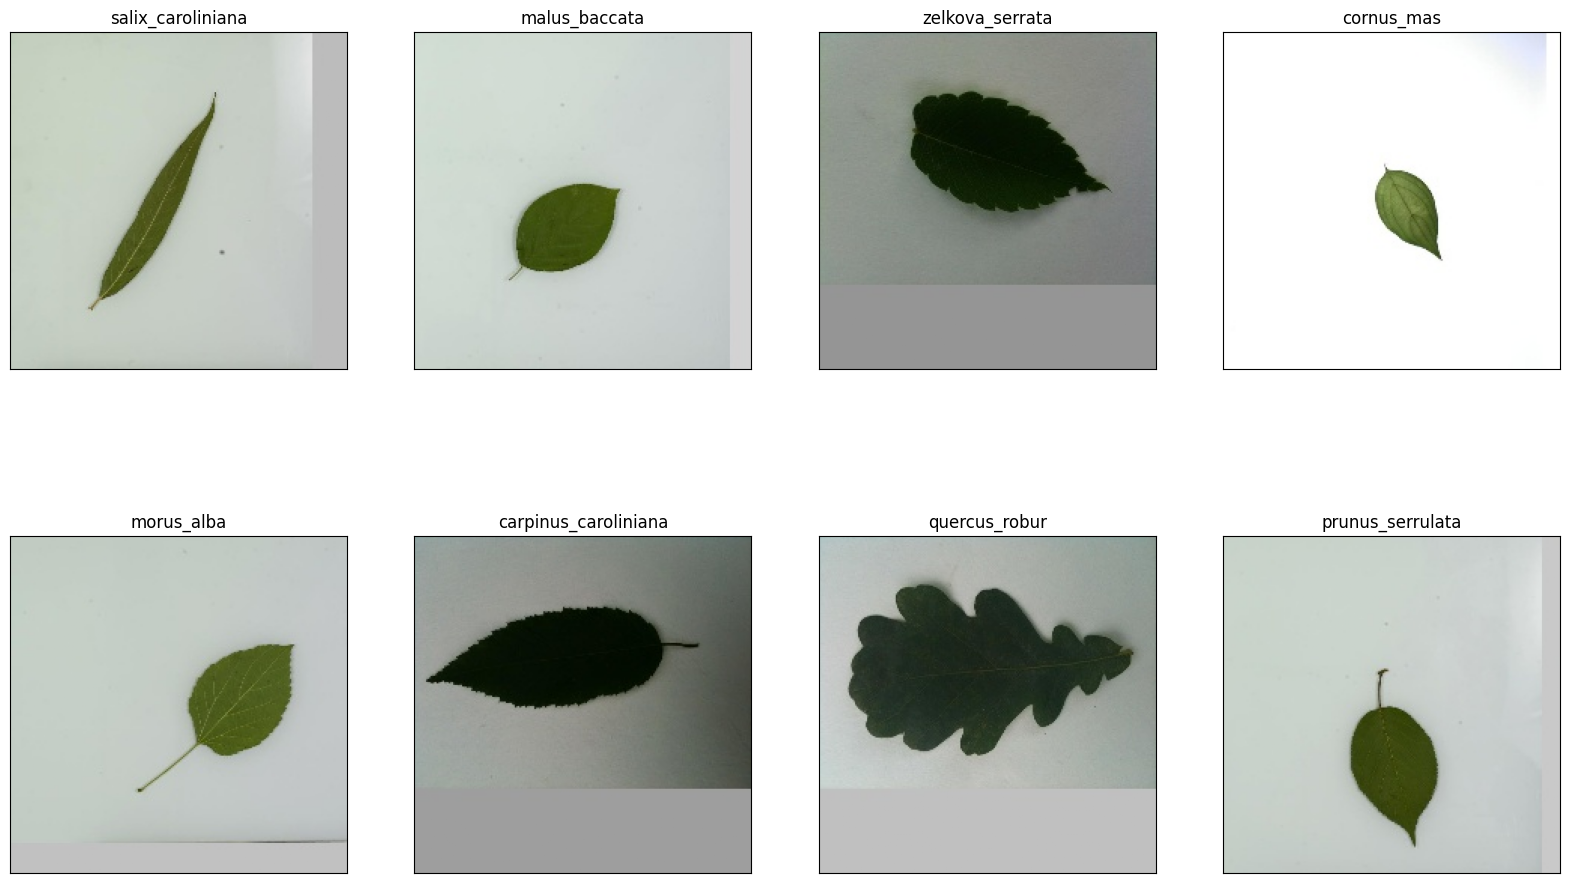

In [66]:
def im_convert(tensor):
    """ 展示数据"""

    image = tensor.to("cpu").clone().detach()
    image = image.numpy().squeeze()
    image = image.transpose(1,2,0)
    image = image.clip(0, 1)

    return image

fig=plt.figure(figsize=(20, 12))
columns = 4
rows = 2

dataiter = iter(val_loader)
inputs, classes = next(dataiter)

for idx in range (columns*rows):
    ax = fig.add_subplot(rows, columns, idx+1, xticks=[], yticks=[])
    ax.set_title(num_to_class[int(classes[idx])])
    plt.imshow(im_convert(inputs[idx]))
plt.show()


In [67]:
#查看gpu
def get_device():
  return "cuda" if torch.cuda.is_available() else "cpu"
device=get_device()
print(device)

cuda


In [68]:
#迁移学习
#决定是否冻结模型参数
def set_parameter_requires_grad(model,feature_extracting):
  if feature_extracting:
    model=model
    for param in model.parameters():
      param.requires_grad=False
def res_model(num_classes,feature_extract=False,use_pretrained=True):
  model_ft=models.resnet34(pretrained=use_pretrained)
  set_parameter_requires_grad(model_ft,feature_extract)
  num_ftrs=model_ft.fc.in_features
  model_ft.fc=nn.Linear(num_ftrs,num_classes)
  return model_ft
#加载ImageNet预训练ResNet34,最后1000类分类层替换成你的叶子分类层



In [69]:
learning_rate = 2e-5
weight_decay = 1e-3
num_epoch = 10
model_path = './pre_res_model.ckpt'

In [70]:
model = res_model(176)
model=model.to(device)
model.device=device

criterion=nn.CrossEntropyLoss()
#交叉熵损失
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate, weight_decay=weight_decay)
#Adam 梯度下降
n_epochs=num_epoch
best_acc=0.0
for epoch in range(n_epochs):
  model.train()# 训练模式
  train_loss=[]
  train_accs=[]
  for batch in tqdm(train_loader):
    imgs,labels=batch
    imgs=imgs.to(device)
    labels=labels.to(device) #放入gpu
    logits=model(imgs)
    loss=criterion(logits,labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    acc=(logits.argmax(dim=-1)==labels).float().mean()
    #每张图选最大类别，当前batch预测正确比例
    train_loss.append(loss.item())
    train_accs.append(acc.item())
  train_loss=sum(train_loss)/len(train_loss)
  train_acc=sum(train_accs)/len(train_accs)
  print(f"[ Train | {epoch + 1:03d}/{n_epochs:03d} ] loss = {train_loss:.5f}, acc = {train_acc:.5f}")
  # Validation
  model.eval() # 测试模式
  valid_loss=[]
  valid_accs=[]
  for batch in tqdm(val_loader):
    imgs,labels=batch
    #测试不用梯度
    with torch.no_grad():
      logits=model(imgs.to(device))
    loss=criterion(logits,labels.to(device))
    acc=(logits.argmax(dim=-1)==labels.to(device)).float().mean()
    valid_loss.append(loss.item())
    valid_accs.append(acc.item())
  valid_loss=sum(valid_loss)/len(valid_loss)
  valid_acc=sum(valid_accs)/len(valid_accs)
  print(f"[ Valid | {epoch + 1:03d}/{n_epochs:03d} ] loss = {valid_loss:.5f}, acc = {valid_acc:.5f}")
  #只保留当前验证集表现最好的模型
  if valid_acc > best_acc:
        best_acc = valid_acc
        torch.save(model.state_dict(), model_path)
        print('saving model with acc {:.3f}'.format(best_acc))





/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 459/459 [01:24<00:00,  5.46it/s]


[ Train | 001/010 ] loss = 3.87471, acc = 0.27683


100%|██████████| 230/230 [00:07<00:00, 29.35it/s]


[ Valid | 001/010 ] loss = 2.74174, acc = 0.46988
saving model with acc 0.470


100%|██████████| 459/459 [01:22<00:00,  5.60it/s]


...

[ Valid | 009/010 ] loss = 0.27503, acc = 0.92147


100%|██████████| 459/459 [01:22<00:00,  5.59it/s]


[ Train | 010/010 ] loss = 0.10310, acc = 0.98278


100%|██████████| 230/230 [00:08<00:00, 27.79it/s]


[ Valid | 010/010 ] loss = 0.26310, acc = 0.92310
saving model with acc 0.923


In [74]:
saveFileName = './submission.csv'
model=res_model(176)
model=model.to(device)
model.load_state_dict(torch.load(model_path))
#测试模式
model.eval()
predictions=[]
for batch in tqdm(test_loader):
  imgs=batch
  with torch.no_grad():
    logits=model(imgs.to(device))
  #找出每张图最大类别
  predictions.extend(logits.argmax(dim=-1).cpu().numpy().tolist())
preds=[]
for i in predictions:
  preds.append(num_to_class[i])
test_data = pd.read_csv(test_path)
test_data["label"]=pd.Series(preds)
submission = pd.concat(
    [test_data['image'],
     test_data['label']],
    axis=1
)
submission.to_csv(saveFileName, index=False)








/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 550/550 [00:20<00:00, 27.15it/s]
